# Logistic Regression - Plecoptera: Perlidae and Trichoptera: Helicopsychidae

Binary logistic regression models for the presence/absence of the two bioindicator taxa in the Cali River. Predictors are screened by AIC over a candidate set, and the selected models are validated with **leave-one-out cross-validation (LOOCV)**.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt

file_path = "../../data/DB - Macroinvertebrados.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df

,COT,DBO5,DBOU,DBO5s,DQO,Dureza,Fósforo,Fosfatos,Hierro,Magnesio,...,pH,Conductividad,OD,Temperatura,Coliformes,Profundidad,Velocidad,Caudal,Perlidae,Trichoptera
0,1.69,2,4,2,10.00,35.5,0.114,0.015,0.236,3.530,...,7.14,80,6.30,15.00,1012,0.44,0.55,1.39,1,0
1,5.24,7,9,5,14.79,124.0,1.640,0.758,6.680,17.400,...,7.40,469,4.33,25.86,11199,0.29,0.52,1.33,0,0
2,2.80,2,3,2,10.00,43.9,0.162,0.155,5.100,2.920,...,7.30,150,5.92,17.00,41,0.32,0.45,0.80,1,1
3,7.92,3,4,2,13.71,113.0,0.050,0.150,0.600,11.800,...,7.92,371,6.82,22.87,9804,0.33,0.71,0.92,0,0
4,12.20,8,10,7,10.00,46.4,0.580,0.150,0.233,3.920,...,7.38,110,6.50,18.40,24196,0.54,0.42,1.69,0,0
5,11.00,2,5,2,10.00,49.4,0.149,0.191,0.831,4.740,...,6.89,115,7.69,20.30,6867,0.36,0.32,1.59,0,0
6,4.33,35,26,15,70.60,108.0,1.500,1.080,0.195,0.378,...,6.94,300,5.05,25.23,19863,0.34,0.66,0.97,0,0
7,7.38,14,35,12,88.50,216.0,0.256,0.221,17.500,24.600,...,7.15,500,3.20,29.30,24196,0.49,0.76,1.50,0,0
8,7.20,2,3,2,10.00,47.5,0.443,0.221,0.100,5.540,...,8.16,112,5.90,18.62,676,0.46,0.42,0.87,0,0
9,3.04,2,3,2,10.00,98.4,0.050,0.150,0.411,11.400,...,7.90,294,7.01,19.94,2613,0.38,0.82,0.83,0,1


## Predictor Selection

The candidate predictors (`DBO5`, `Dureza`, `Caudal`) come from a 3-variable PCA. All subsets are fitted as binomial GLMs and ranked by AIC. The best subset for Perlidae turned out to be `DBO5` alone.

In [2]:
predictors = ['DBO5', 'Dureza', 'Caudal']  # candidate predictors (from a 3-variable PCA)
response = ['Perlidae']
X = df[predictors]
y = df[response]

n_variables = X.shape[1]
print(f"Maximum number of possible models: {2**n_variables - 1}")

Maximum number of possible models: 7


In [3]:
def select_model(dataframe, predictors, response):
    """Exhaustive AIC-based subset selection for a binomial GLM."""
    best_model = None
    best_aic = np.inf
    best_combination = None
    total_combinations = 0

    for L in range(1, len(predictors) + 1):
        for subset in combinations(predictors, L):
            total_combinations += 1
            X_subset = sm.add_constant(dataframe[list(subset)])
            result = sm.GLM(dataframe[response], X_subset,
                            family=sm.families.Binomial()).fit()
            print(f'Trying model with predictors: {subset}, AIC: {result.aic}')
            if result.aic < best_aic:
                best_aic = result.aic
                best_model = result
                best_combination = subset

    print(f'Total combinations tried: {total_combinations}')
    print(f'Best model has predictors: {best_combination} with AIC: {best_aic}')
    return best_model

best_model = select_model(df, predictors, response)
print(best_model.summary())

Trying model with predictors: ('DBO5',), AIC: 20.63553233899094
Trying model with predictors: ('Dureza',), AIC: 22.768566037335802
Trying model with predictors: ('Caudal',), AIC: 26.07031930892377
Trying model with predictors: ('DBO5', 'Dureza'), AIC: 21.925301100120826
Trying model with predictors: ('DBO5', 'Caudal'), AIC: 22.103629641721614
Trying model with predictors: ('Dureza', 'Caudal'), AIC: 24.410746673856327
Trying model with predictors: ('DBO5', 'Dureza', 'Caudal'), AIC: 23.507058781030157
Total combinations tried: 7
Best model has predictors: ('DBO5',) with AIC: 20.63553233899094
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Perlidae   No. Observations:                   18
Model:                            GLM   Df Residuals:                       16
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:

## Model Definition & Evaluation

### Perlidae - model with DBO5 (LOOCV)

Predictors are standardised; the logistic model uses an L2 penalty with balanced class weights. Both validation (held-out) and calibration (training) metrics are reported.

## Methodological note: class_weight='balanced'

`class_weight='balanced'` was set because both taxa show class imbalance:
- Perlidae: 7 presences / 11 absences (39% / 61%)
- Helicopsychidae: 3 presences / 15 absences (17% / 83%)

Without balancing, the model would be biased toward predicting the majority
class (absence). The 'balanced' setting weights each class inversely
proportional to its frequency, ensuring the model learns from minority-class
(presence) observations despite their low count.

This approach is consistent with established practice for imbalanced
ecological presence/absence datasets (see e.g. Kuhn & Johnson, 2013).

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

X = df[['DBO5']]
y = df['Perlidae']
X_scaled = StandardScaler().fit_transform(X)

model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                           random_state=42, class_weight='balanced')
loo = LeaveOneOut()

y_true_val, y_pred_val = [], []
y_true_cal, y_pred_cal = [], []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    # Validation (held-out observation)
    y_true_val.append(y_test.iloc[0])
    y_pred_val.append(model.predict(X_test)[0])

    # Calibration (training observations)
    y_true_cal.extend(y_train.values.tolist())
    y_pred_cal.extend(model.predict(X_train).tolist())

print("Confusion matrix - validation (LOOCV):")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification report - validation (LOOCV):")
print(classification_report(y_true_val, y_pred_val))

print("Confusion matrix - calibration:")
print(confusion_matrix(y_true_cal, y_pred_cal))
print("\nClassification report - calibration:")
print(classification_report(y_true_cal, y_pred_cal))

Confusion matrix - validation (LOOCV):
[[5 7]
 [0 6]]

Classification report - validation (LOOCV):
              precision    recall  f1-score   support

           0       1.00      0.42      0.59        12
           1       0.46      1.00      0.63         6

    accuracy                           0.61        18
   macro avg       0.73      0.71      0.61        18
weighted avg       0.82      0.61      0.60        18

Confusion matrix - calibration:
[[ 85 119]
 [  0 102]]

Classification report - calibration:
              precision    recall  f1-score   support

           0       1.00      0.42      0.59       204
           1       0.46      1.00      0.63       102

    accuracy                           0.61       306
   macro avg       0.73      0.71      0.61       306
weighted avg       0.82      0.61      0.60       306



C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty

### Trichoptera: Helicopsychidae - model with DBO5 (LOOCV)

In [5]:
X = df[['DBO5']]
y = df['Trichoptera']
X_scaled = StandardScaler().fit_transform(X)

model_trich = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                                 random_state=42, class_weight='balanced')
loo = LeaveOneOut()

y_true_val, y_pred_val = [], []
y_true_cal, y_pred_cal = [], []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_trich.fit(X_train, y_train)

    y_true_val.append(y_test.iloc[0])
    y_pred_val.append(model_trich.predict(X_test)[0])

    y_true_cal.extend(y_train.values.tolist())
    y_pred_cal.extend(model_trich.predict(X_train).tolist())

print("Confusion matrix - validation (LOOCV):")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification report - validation (LOOCV):")
print(classification_report(y_true_val, y_pred_val))

print("Confusion matrix - calibration:")
print(confusion_matrix(y_true_cal, y_pred_cal))
print("\nClassification report - calibration:")
print(classification_report(y_true_cal, y_pred_cal))

Confusion matrix - validation (LOOCV):
[[ 5 10]
 [ 0  3]]

Classification report - validation (LOOCV):
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        15
           1       0.23      1.00      0.38         3

    accuracy                           0.44        18
   macro avg       0.62      0.67      0.44        18
weighted avg       0.87      0.44      0.48        18

Confusion matrix - calibration:
[[ 85 170]
 [  0  51]]

Classification report - calibration:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50       255
           1       0.23      1.00      0.38        51

    accuracy                           0.44       306
   macro avg       0.62      0.67      0.44       306
weighted avg       0.87      0.44      0.48       306



C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty

## Note on Helicopsychidae model performance

The low accuracy (0.44) and the asymmetric confusion matrix reflect the
severe class imbalance in Helicopsychidae observations (3 presences of 18,
17%). With only 3 positive cases, the LOOCV cannot reliably estimate
generalisation performance for the minority class. These results should be
interpreted with caution. The high recall for class 1 (1.00) indicates the
model correctly identifies all presences but at the cost of many false
positives. Cohen's Kappa is the most informative metric under these
conditions.

## Visualisation

Fitted logistic curves (predicted probability vs BOD5) for each taxon. To draw the curves we refit each single-predictor model on the standardised range; here the curves use the unstandardised coefficients stored after the LOOCV loop.

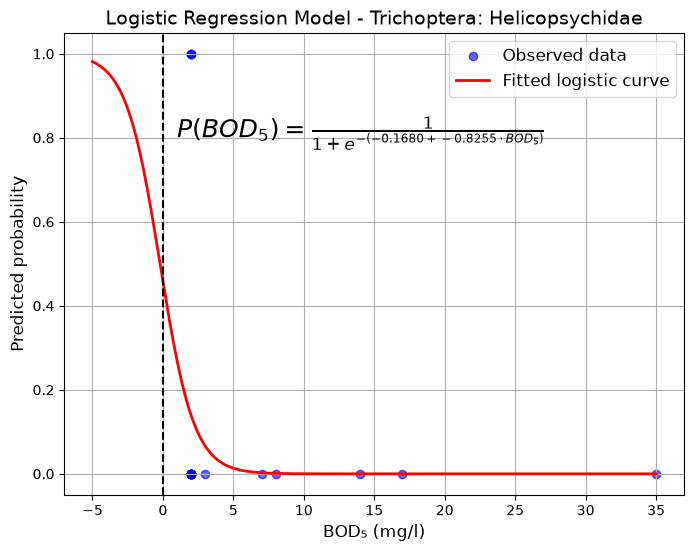

In [6]:
# Helicopsychidae fitted curve
intercept = model_trich.intercept_[0]
coefficient = model_trich.coef_[0][0]
X_continuous = np.linspace(-5, df['DBO5'].max(), 300)
y_curve = 1 / (1 + np.exp(-(intercept + coefficient * X_continuous)))

plt.figure(figsize=(8, 6))
plt.scatter(df['DBO5'], df['Trichoptera'], color='blue', alpha=0.6, label='Observed data')
plt.plot(X_continuous, y_curve, color='red', linewidth=2, label='Fitted logistic curve')
plt.title('Logistic Regression Model - Trichoptera: Helicopsychidae', fontsize=14)
plt.xlabel('BOD₅ (mg/l)', fontsize=12)
plt.ylabel('Predicted probability', fontsize=12)
plt.legend(fontsize=12)
equation = f'$P(BOD_5) = \\frac{{1}}{{1 + e^{{-({intercept:.4f} + {coefficient:.4f} \\cdot BOD_5)}}}}$'
plt.text(1, 0.8, equation, fontsize=18, color='black')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(True)
plt.savefig("../../figures/logistic_Helicopsychidae.png", dpi=300, bbox_inches="tight")
plt.show()

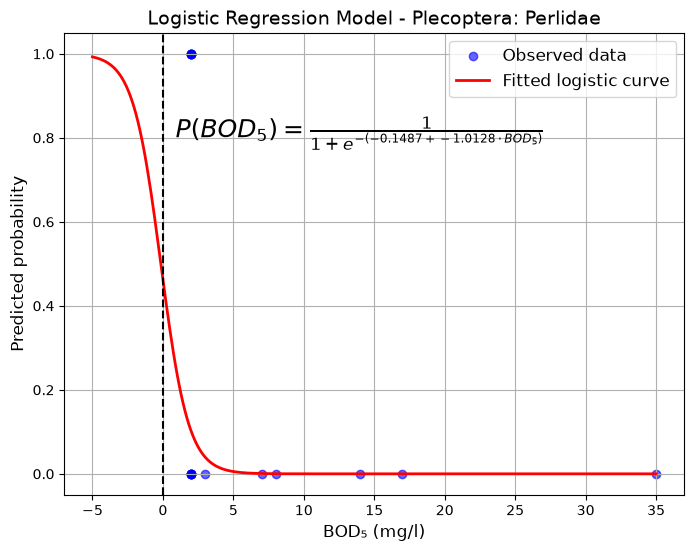

In [7]:
# Perlidae fitted curve
intercept = model.intercept_[0]
coefficient = model.coef_[0][0]
X_continuous = np.linspace(-5, df['DBO5'].max(), 300)
y_curve = 1 / (1 + np.exp(-(intercept + coefficient * X_continuous)))

plt.figure(figsize=(8, 6))
plt.scatter(df['DBO5'], df['Perlidae'], color='blue', alpha=0.6, label='Observed data')
plt.plot(X_continuous, y_curve, color='red', linewidth=2, label='Fitted logistic curve')
plt.title('Logistic Regression Model - Plecoptera: Perlidae', fontsize=14)
plt.xlabel('BOD₅ (mg/l)', fontsize=12)
plt.ylabel('Predicted probability', fontsize=12)
plt.legend(fontsize=12)
equation = f'$P(BOD_5) = \\frac{{1}}{{1 + e^{{-({intercept:.4f} + {coefficient:.4f} \\cdot BOD_5)}}}}$'
plt.text(0.9, 0.8, equation, fontsize=18, color='black')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(True)
plt.savefig("../../figures/logistic_Perlidae.png", dpi=300, bbox_inches="tight")
plt.show()

## Cohen's Kappa and metric export (for the master table)

In [8]:
# Cohen's Kappa for both taxa (LOOCV validation) and export of metrics for the
# master results table. Re-runs the two single-predictor (DBO5) LOOCV models so the
# exported numbers are self-contained and reproducible.
from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support, accuracy_score
import pandas as pd

def logit_loocv_metrics(y_col):
    Xs = StandardScaler().fit_transform(df[['DBO5']])
    yy = df[y_col]
    loo = LeaveOneOut()
    yt, yp = [], []
    clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                             random_state=42, class_weight='balanced')
    for tr, te in loo.split(Xs):
        clf.fit(Xs[tr], yy.iloc[tr])
        yt.append(yy.iloc[te].values[0]); yp.append(clf.predict(Xs[te])[0])
    p, r, f, _ = precision_recall_fscore_support(yt, yp, labels=[0, 1], average='macro', zero_division=0)
    return {'precision': p, 'recall': r, 'f1': f,
            'accuracy': accuracy_score(yt, yp), 'kappa': cohen_kappa_score(yt, yp)}

rows = []
for taxon, col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    m = logit_loocv_metrics(col)
    print(f"{taxon}: accuracy={m['accuracy']:.3f}  Cohen's Kappa={m['kappa']:.3f}")
    rows.append({'target': taxon, 'technique': 'Logistic regression', 'validation': 'LOOCV',
                 'n': 18, 'precision': round(m['precision'], 3), 'recall': round(m['recall'], 3),
                 'f1': round(m['f1'], 3), 'accuracy': round(m['accuracy'], 3), 'kappa': round(m['kappa'], 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_logistic.csv", index=False)
print("Saved outputs/metrics_logistic.csv")

Perlidae: accuracy=0.611  Cohen's Kappa=0.323
Helicopsychidae: accuracy=0.444  Cohen's Kappa=0.143
Saved outputs/metrics_logistic.csv


C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASUS\Desktop\S\Trabajo de grado\Scripts de práctica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty